# Experiment No. 3
## Principal Component Analysis (PCA)

### Aim
To apply Principal Component Analysis (PCA) on a multivariate dataset in order to reduce its dimensionality, visualize the data in lower dimensions, and evaluate the amount of variance retained after transformation.

### Objectives

- To understand the concept and mathematical foundation of PCA for dimensionality reduction.
- To preprocess the dataset by handling scaling/normalization before applying PCA.
- To transform the high-dimensional dataset into a lower-dimensional space using PCA.
- To visualize the transformed data in 2D/3D plots.
- To calculate and analyze the percentage of variance explained by each principal component.
- To evaluate the effectiveness of PCA in retaining maximum variance with fewer dimensions.
- To interpret the results and understand the trade-off between dimensionality reduction and information loss.

### Relevance

PCA is important in machine learning because it reduces high-dimensional data into fewer dimensions while retaining most of the information. It helps simplify datasets, improve visualization, reduce computational cost, and can be used as a preprocessing step for classification and clustering.

### Step 1: Importing Required Libraries

The required libraries are imported for data handling, data standardization, PCA, model training, evaluation, and visualization.

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Creating Sample Dataset

A small dataset is created with three numerical features: Height, Weight, and Age. Gender is used as the target variable, where 1 represents Male and 0 represents Female.

In [2]:
data = {
    'Height': [170, 165, 180, 175, 160, 172, 168, 177, 162, 158],
    'Weight': [65, 59, 75, 68, 55, 70, 62, 74, 58, 54],
    'Age': [30, 25, 35, 28, 22, 32, 27, 33, 24, 21],
    'Gender': [1, 0, 1, 1, 0, 1, 0, 1, 0, 0]  # 1 = Male, 0 = Female
}

df = pd.DataFrame(data)
print(df)

   Height  Weight  Age  Gender
0     170      65   30       1
1     165      59   25       0
2     180      75   35       1
3     175      68   28       1
4     160      55   22       0
5     172      70   32       1
6     168      62   27       0
7     177      74   33       1
8     162      58   24       0
9     158      54   21       0


### Step 3: Standardizing the Data

The features have different scales, so standardization is performed before applying PCA. Standardization makes the features comparable by giving them a mean of 0 and a standard deviation of 1.

In [3]:
X = df.drop('Gender', axis=1)
y = df['Gender']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

### Step 4: Applying PCA Algorithm

PCA is applied to reduce the three original features into two principal components. The transformed data is then divided into training and testing sets for classification.

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

The explained variance ratio shows how much information or variance is retained by each principal component.

In [5]:
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance Retained:", pca.explained_variance_ratio_.sum())

Explained Variance Ratio: [0.94041611 0.04378473]
Total Variance Retained: 0.9842008396200406


The Logistic Regression model is trained using the PCA-transformed training data and then used to predict the Gender labels of the test data.

In [6]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Step 5: Evaluating with Confusion Matrix

The confusion matrix compares the actual labels with the predicted labels and shows the number of correct and incorrect predictions.

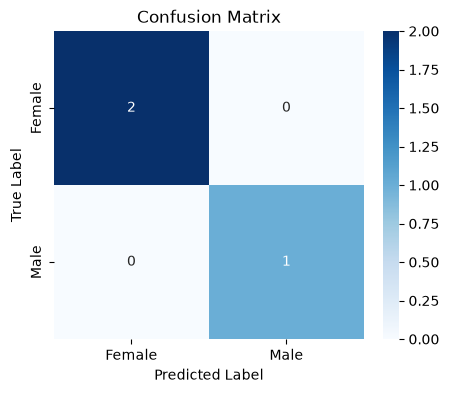

In [7]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Female', 'Male'],
    yticklabels=['Female', 'Male']
)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Step 6: Visualizing PCA Result

The data is visualized before and after PCA. The first plot shows the original standardized features, while the second plot shows the data projected onto the two principal components.

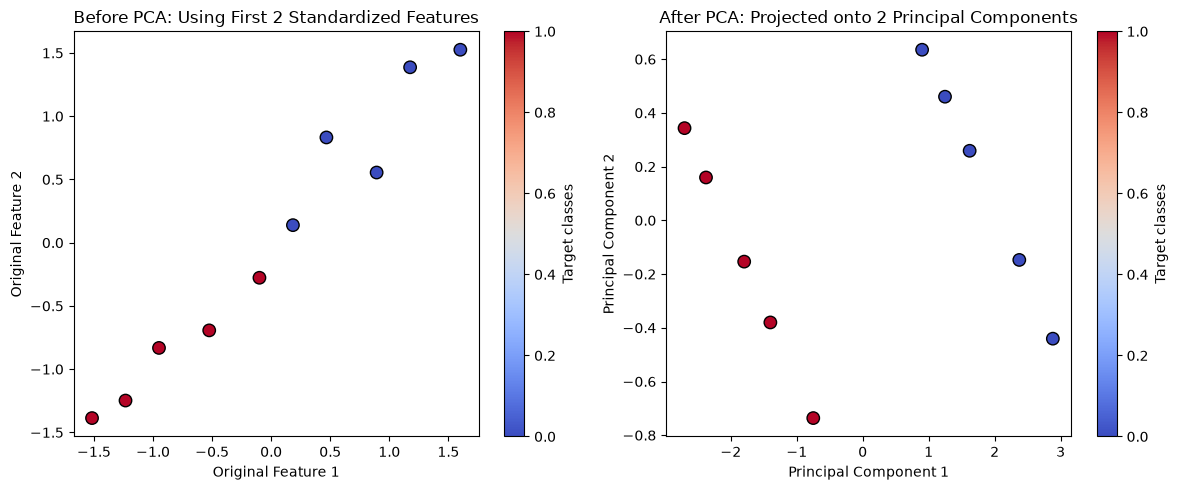

In [8]:
y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y_numeric,
    cmap='coolwarm',
    edgecolor='k',
    s=80
)
plt.xlabel('Original Feature 1')
plt.ylabel('Original Feature 2')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='Target classes')

plt.subplot(1, 2, 2)
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_numeric,
    cmap='coolwarm',
    edgecolor='k',
    s=80
)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='Target classes')

plt.tight_layout()
plt.show()

## Conclusion

PCA was successfully applied to the sample multivariate dataset to reduce its dimensionality from three features to two principal components. The data was standardized before PCA, and the transformed data was used for Logistic Regression classification. A confusion matrix was used to evaluate the predictions, and the PCA results were visualized before and after transformation. The explained variance ratio was also calculated to understand how much information was retained after dimensionality reduction.